In [11]:
pip install duckdb


   ---------------------------------------- 0.0/13.1 MB ? eta -:--:--
   ---- ----------------------------------- 1.6/13.1 MB 12.5 MB/s eta 0:00:01
   --------------- ------------------------ 5.2/13.1 MB 16.1 MB/s eta 0:00:01
   ------------------------------- -------- 10.2/13.1 MB 19.0 MB/s eta 0:00:01
   ---------------------------------------- 13.1/13.1 MB 18.8 MB/s eta 0:00:00


In [14]:
pip install seaborn 

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt

In [46]:
df = pd.read_csv(r"C:\Users\Naren karthikeyan\Downloads\Dataset for Data Analytics Cleaned.csv")
df.head()


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,04-01-2023 00:00,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,23-08-2024 00:00,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,27-02-2024 00:00,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,15-10-2023 00:00,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,08-05-2025 00:00,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [47]:
df.info()
df.shape
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       1200 non-null   object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [6]:
status_df = duckdb.sql("""

    SELECT
        OrderStatus,
        COUNT(*) AS total_orders

    FROM df

    GROUP BY OrderStatus
    ORDER BY total_orders DESC

""").df()

status_df

,OrderStatus,total_orders
0,Cancelled,250
1,Returned,247
2,Pending,237
3,Shipped,235
4,Delivered,231


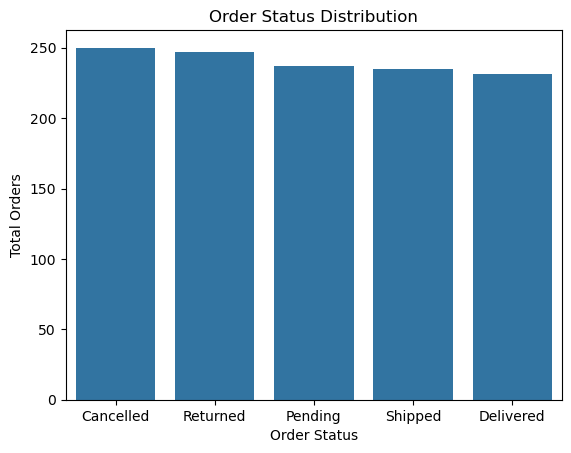

In [7]:
sns.barplot(
    data=status_df,
    x='OrderStatus',
    y='total_orders'
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Total Orders")

plt.show()

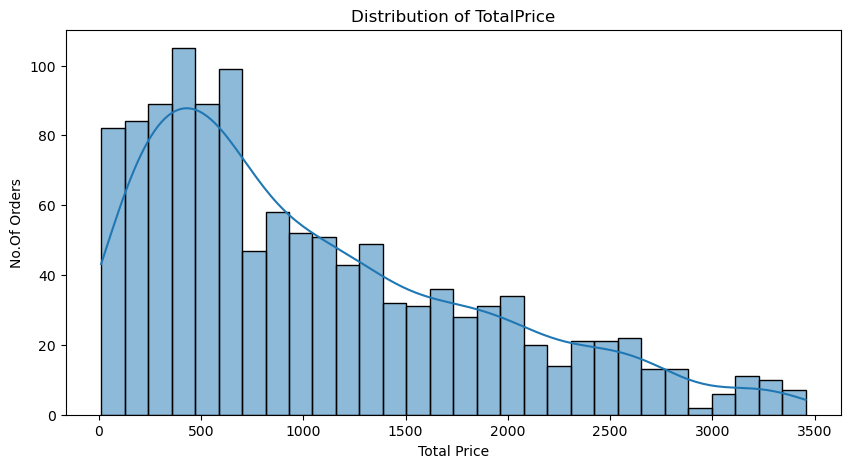

In [10]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['TotalPrice'],
    bins=30,
    kde=True
)

plt.title("Distribution of TotalPrice")
plt.xlabel("Total Price")
plt.ylabel("No.Of Orders")

plt.show()

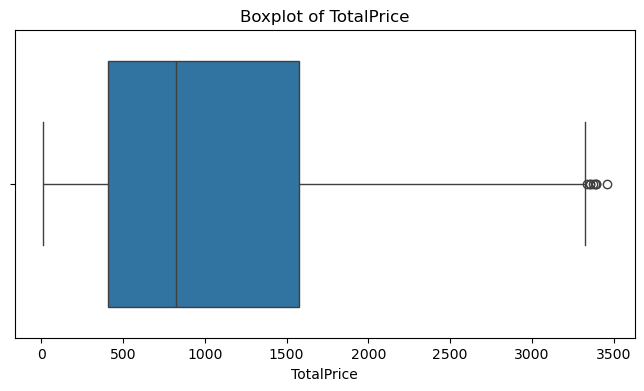

In [9]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df['TotalPrice']
)

plt.title("Boxplot of TotalPrice")

plt.show()

In [11]:
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + (1.5 * IQR)

outliers = df[df['TotalPrice'] > upper_limit]

outliers[['OrderID', 'CustomerID', 'Product',
          'Quantity', 'ItemsInCart',
          'TotalPrice']].head(10)

,OrderID,CustomerID,Product,Quantity,ItemsInCart,TotalPrice
107,ORD200107,C16775,Printer,5,8,3353.75
326,ORD200326,C65986,Laptop,5,5,3352.40
328,ORD200328,C18404,Tablet,5,7,3370.20
469,ORD200469,C13877,Chair,5,5,3384.90
632,ORD200632,C67260,Laptop,5,7,3390.80
789,ORD200789,C57276,Tablet,5,10,3456.40
1065,ORD201065,C47778,Printer,5,7,3334.00
1122,ORD201122,C38840,Monitor,5,8,3390.95


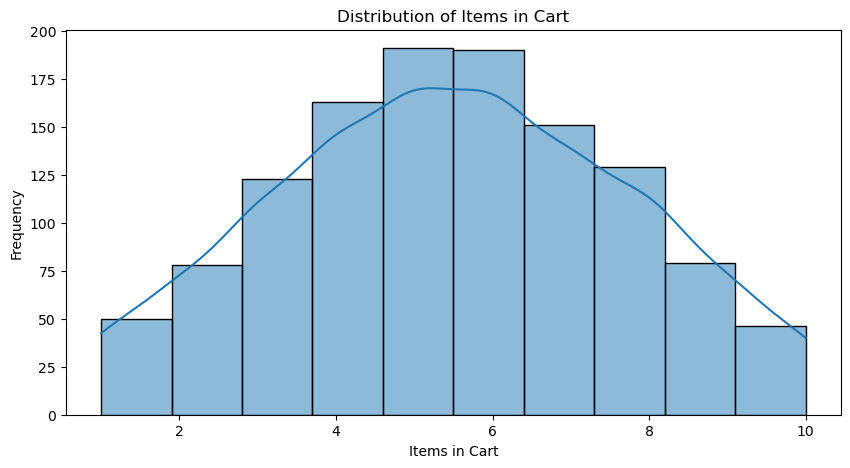

In [14]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['ItemsInCart'],
    bins=10,
    kde=True
)

plt.title("Distribution of Items in Cart")
plt.xlabel("Items in Cart")
plt.ylabel("Frequency")

plt.show()

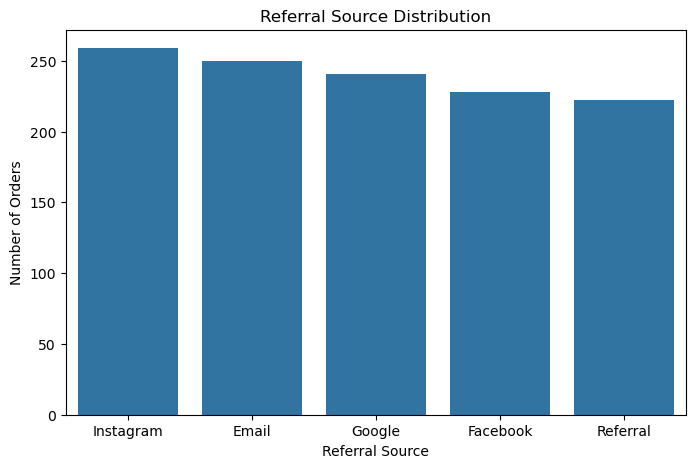

In [27]:
dz =duckdb.sql("""
SELECT
	ReferralSource,
	COUNT(ReferralSource) AS ref_Source,
FROM df
GROUP BY ReferralSource
ORDER BY ref_Source DESC""").df()

plt.figure(figsize=(8,5))

sns.barplot(
    data=dz,
    x='ReferralSource',
    y='ref_Source'
)

plt.title("Referral Source Distribution")
plt.xlabel("Referral Source")
plt.ylabel("Number of Orders")

plt.show()

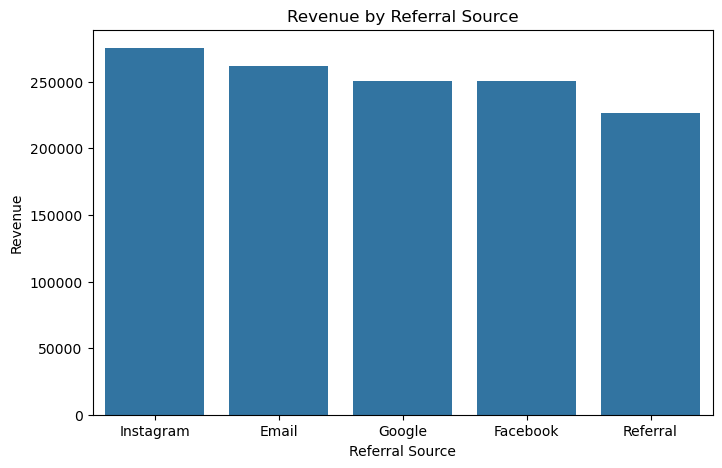

In [31]:
ref_revenue = duckdb.sql("""
    SELECT
	ReferralSource,
	SUM(TotalPrice) AS revenue
FROM df
GROUP BY ReferralSource
ORDER BY revenue DESC """).df()

plt.figure(figsize=(8,5))

sns.barplot(
    data=ref_revenue,
    x='ReferralSource',
    y='revenue'
)

plt.title("Revenue by Referral Source")
plt.xlabel("Referral Source")
plt.ylabel("Revenue")

plt.show()

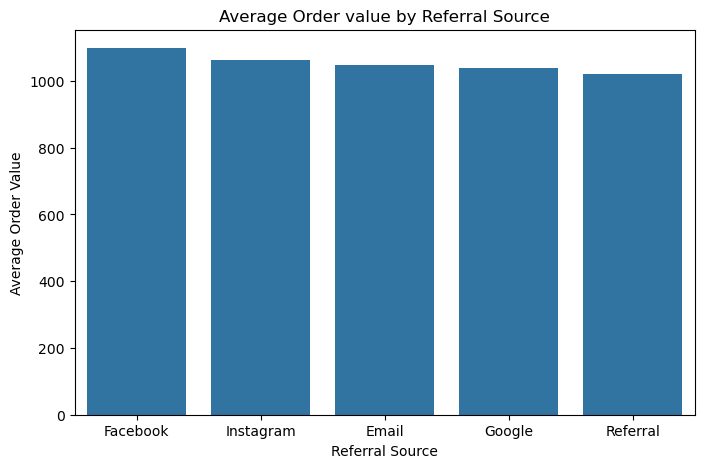

In [33]:
ref_revenue = duckdb.sql("""
    SELECT
	ReferralSource,
	AVG(TotalPrice) AS avg_order_value
FROM df
GROUP BY ReferralSource
ORDER BY avg_order_value DESC """).df()

plt.figure(figsize=(8,5))

sns.barplot(
    data=ref_revenue,
    x='ReferralSource',
    y='avg_order_value'
)

plt.title("Average Order value by Referral Source")
plt.xlabel("Referral Source")
plt.ylabel("Average Order Value")

plt.show()

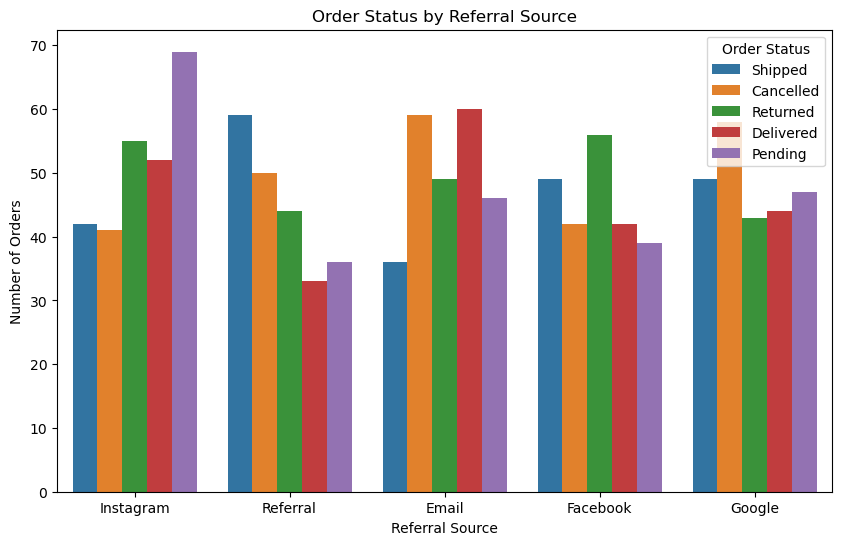

In [35]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='ReferralSource',
    hue='OrderStatus'
)

plt.title("Order Status by Referral Source")
plt.xlabel("Referral Source")
plt.ylabel("Number of Orders")

plt.legend(title='Order Status')

plt.show()

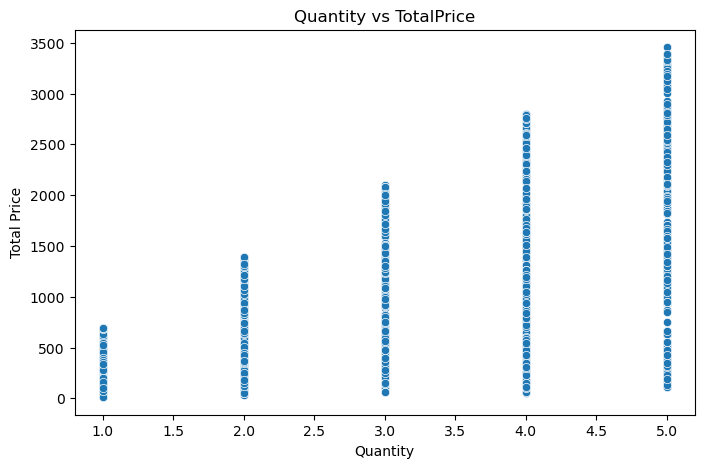

In [37]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Quantity',
    y='TotalPrice'
)

plt.title("Quantity vs TotalPrice")
plt.xlabel("Quantity")
plt.ylabel("Total Price")

plt.show()

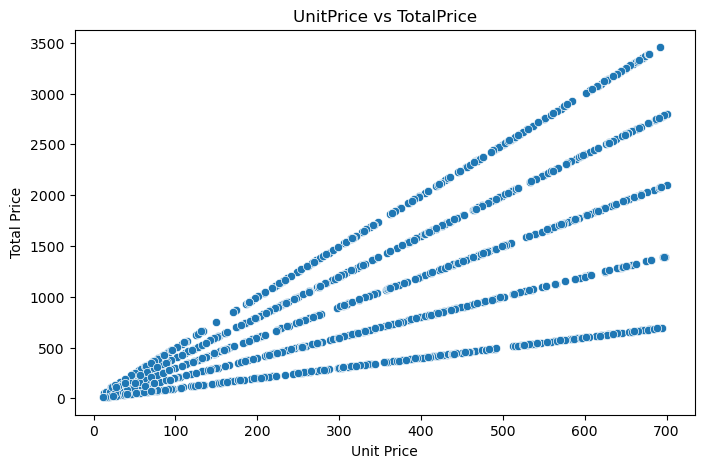

In [38]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='UnitPrice',
    y='TotalPrice'
)

plt.title("UnitPrice vs TotalPrice")
plt.xlabel("Unit Price")
plt.ylabel("Total Price")

plt.show()

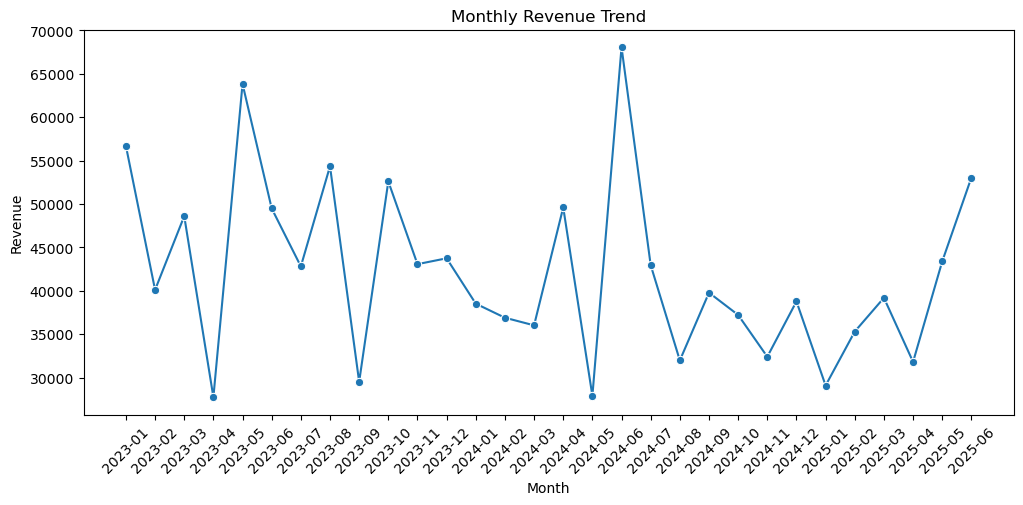

In [39]:
monthly_revenue = df.groupby(
    df['Date'].dt.to_period('M')
)['TotalPrice'].sum().reset_index()

monthly_revenue['Date'] = monthly_revenue['Date'].astype(str)

plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_revenue,
    x='Date',
    y='TotalPrice',
    marker='o'
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

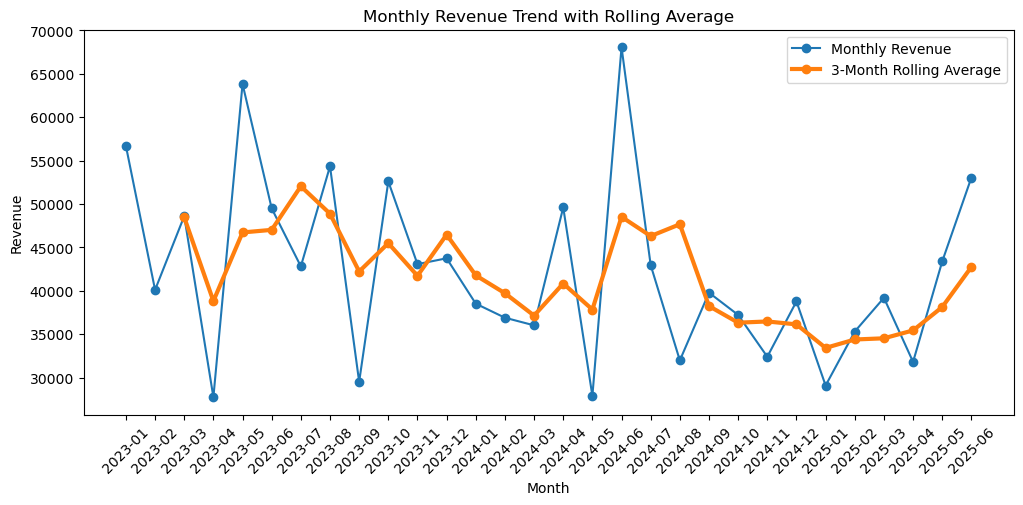

In [40]:
monthly_revenue['Rolling_Avg'] = (
    monthly_revenue['TotalPrice']
    .rolling(window=3)
    .mean()
)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_revenue['Date'],
    monthly_revenue['TotalPrice'],
    marker='o',
    label='Monthly Revenue'
)

plt.plot(
    monthly_revenue['Date'],
    monthly_revenue['Rolling_Avg'],
    marker='o',
    linewidth=3,
    label='3-Month Rolling Average'
)

plt.title("Monthly Revenue Trend with Rolling Average")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.legend()

plt.show()

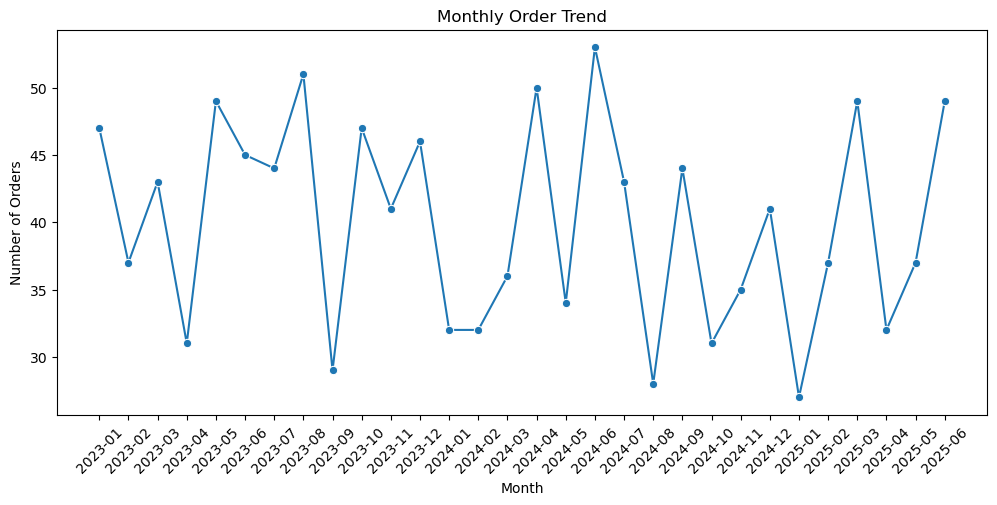

In [41]:
monthly_orders = df.groupby(
    df['Date'].dt.to_period('M')
).size().reset_index(name='orders')

monthly_orders['Date'] = monthly_orders['Date'].astype(str)

plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_orders,
    x='Date',
    y='orders',
    marker='o'
)

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.show()

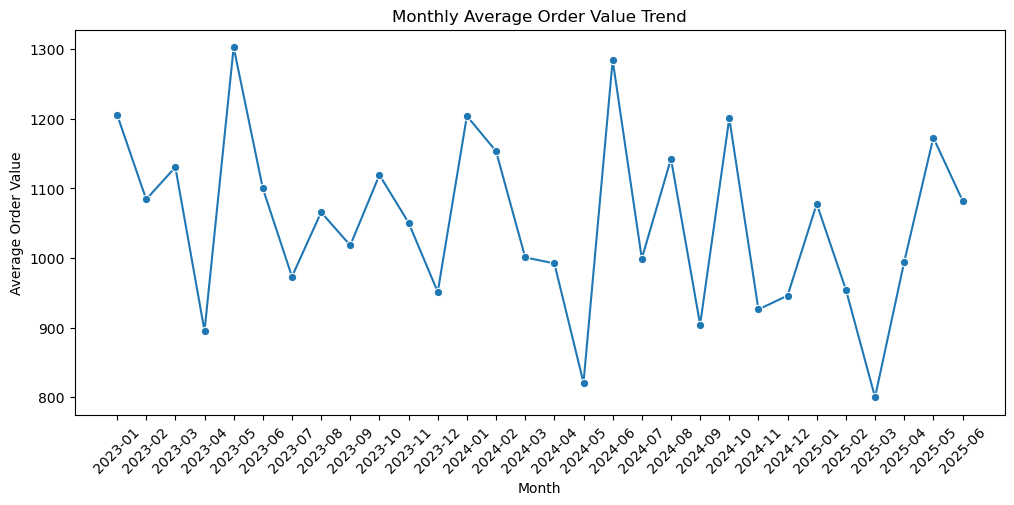

In [42]:
monthly_aov = df.groupby(
    df['Date'].dt.to_period('M')
)['TotalPrice'].mean().reset_index()

monthly_aov['Date'] = monthly_aov['Date'].astype(str)

plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_aov,
    x='Date',
    y='TotalPrice',
    marker='o'
)

plt.title("Monthly Average Order Value Trend")
plt.xlabel("Month")
plt.ylabel("Average Order Value")

plt.xticks(rotation=45)

plt.show()

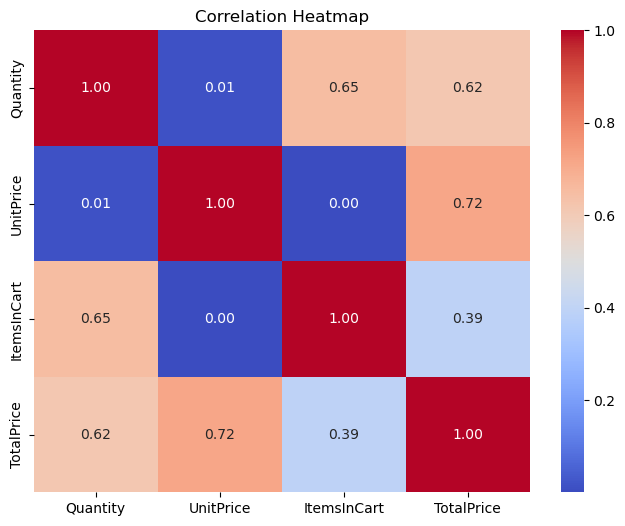

In [48]:
numeric_df = df.select_dtypes(include='number')


corr_matrix = numeric_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

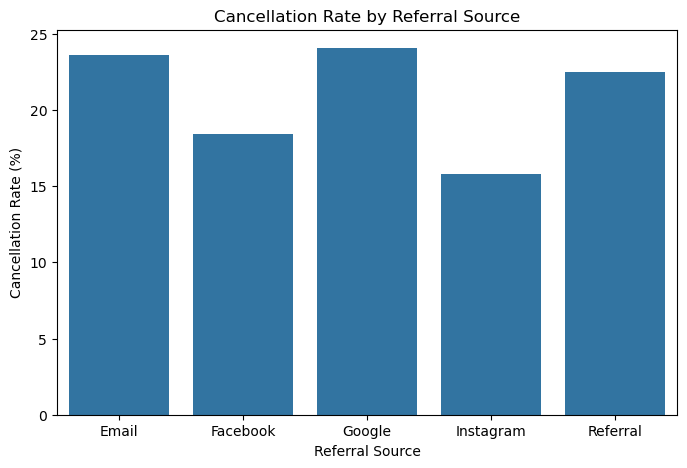

In [49]:
cancel_df = (
    df.groupby('ReferralSource')['OrderStatus']
    .apply(lambda x: (x == 'Cancelled').mean() * 100)
    .reset_index(name='CancellationRate')
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=cancel_df,
    x='ReferralSource',
    y='CancellationRate'
)

plt.title("Cancellation Rate by Referral Source")
plt.xlabel("Referral Source")
plt.ylabel("Cancellation Rate (%)")

plt.show()

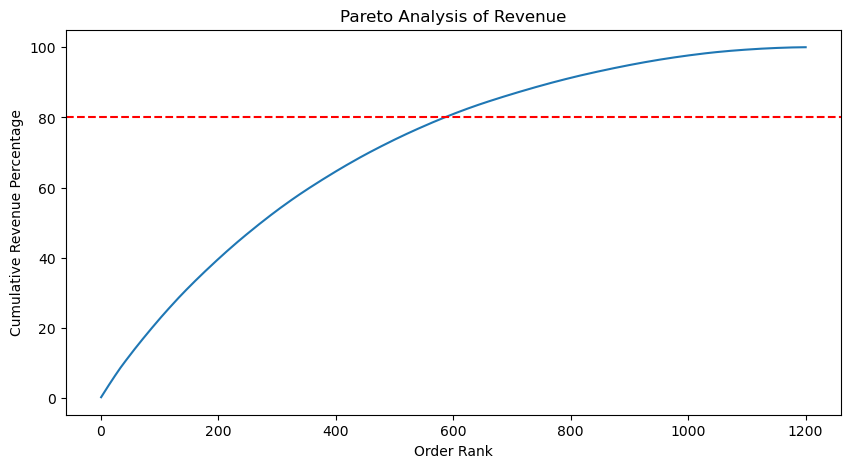

In [50]:
pareto_df = df[['OrderID', 'TotalPrice']].sort_values(
    by='TotalPrice',
    ascending=False
)

pareto_df['CumulativeRevenue'] = (
    pareto_df['TotalPrice'].cumsum()
)

total_revenue = pareto_df['TotalPrice'].sum()

pareto_df['CumulativePercentage'] = (
    pareto_df['CumulativeRevenue'] / total_revenue
) * 100

pareto_df['OrderRank'] = range(1, len(pareto_df) + 1)

plt.figure(figsize=(10,5))

plt.plot(
    pareto_df['OrderRank'],
    pareto_df['CumulativePercentage']
)

plt.axhline(80, color='red', linestyle='--')

plt.title("Pareto Analysis of Revenue")
plt.xlabel("Order Rank")
plt.ylabel("Cumulative Revenue Percentage")

plt.show()